In [13]:
import os
from pathlib import Path
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from PIL import Image

dataset_path = Path("../data/raw")
IMAGES_SUBDIR = "images"
MASKS_SUBDIR = "masks"


In [28]:
covid_metadata=pd.read_excel(dataset_path / "COVID.metadata.xlsx")
covid_metadata.head()
covid_metadata.info()
covid_metadata.isnull().sum()

lung_opacity_metadata=pd.read_excel(dataset_path / "Lung_Opacity.metadata.xlsx")
lung_opacity_metadata.head()
lung_opacity_metadata.info()
lung_opacity_metadata.isnull().sum()

normal_metadata=pd.read_excel(dataset_path / "Normal.metadata.xlsx")
normal_metadata.head()
normal_metadata.info()
normal_metadata.isnull().sum()

viral_pneumonia_metadata=pd.read_excel(dataset_path / "Viral Pneumonia.metadata.xlsx")
viral_pneumonia_metadata.head()
viral_pneumonia_metadata.info()
viral_pneumonia_metadata.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3616 entries, 0 to 3615
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   FILE NAME  3616 non-null   object
 1   FORMAT     3616 non-null   object
 2   SIZE       3616 non-null   object
 3   URL        3616 non-null   object
dtypes: object(4)
memory usage: 113.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6012 entries, 0 to 6011
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   FILE NAME  6012 non-null   object
 1   FORMAT     6012 non-null   object
 2   SIZE       6012 non-null   object
 3   URL        6012 non-null   object
dtypes: object(4)
memory usage: 188.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10192 entries, 0 to 10191
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   FILE NAME  10192 non-null  object
 1   FORMAT

FILE NAME    0
FORMAT       0
SIZE         0
URL          0
dtype: int64

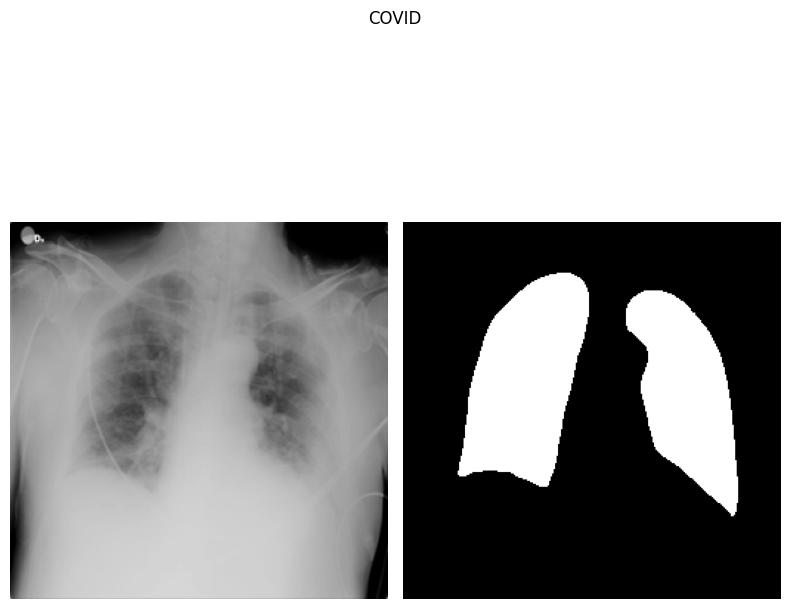

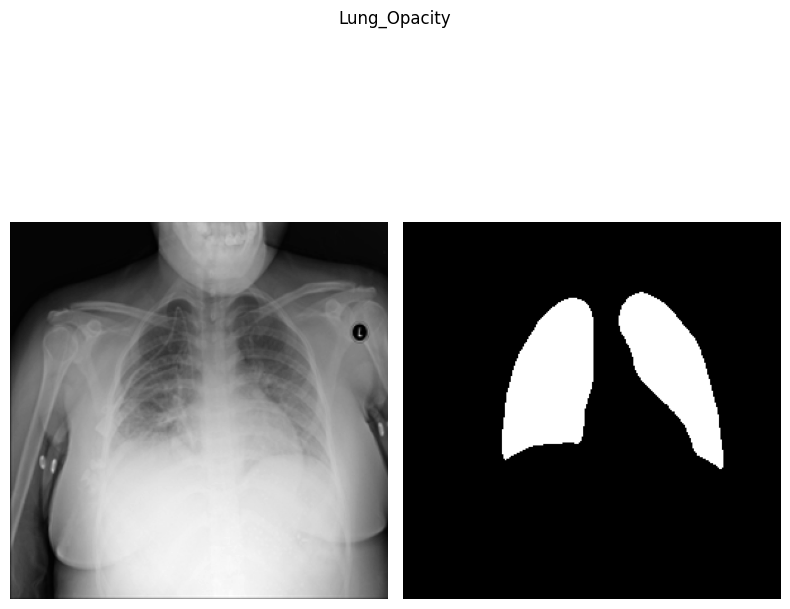

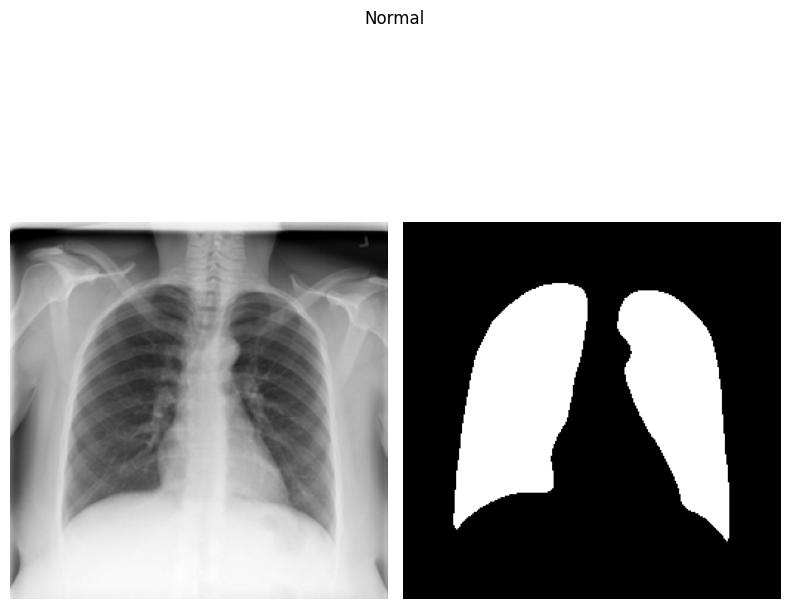

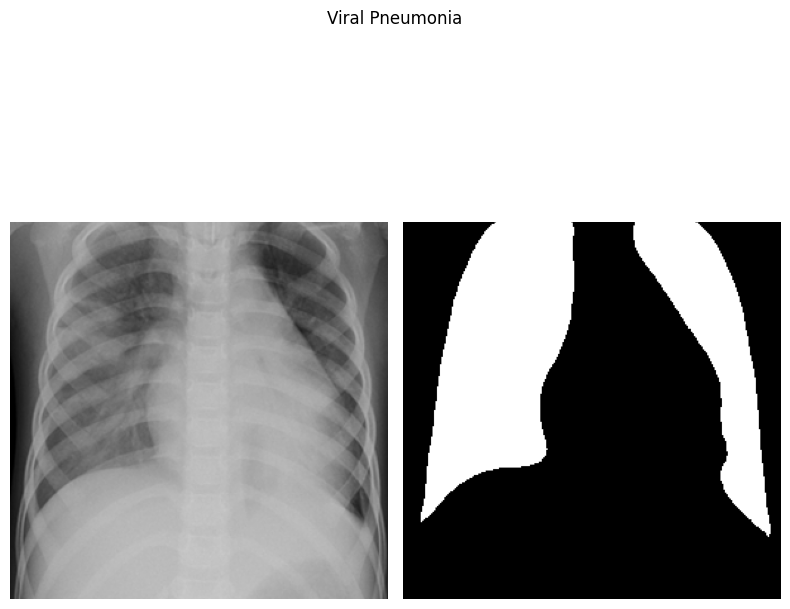

In [5]:
from PIL import Image          #Python Imaging Library (PIL): It provides functions to load, process and save images.

classes = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]



for c in classes:
    fig = plt.figure(figsize=(8,8)) #große Zeichenfläche erstellen
    plt.subplot(121)
    plt.suptitle(c)
    folder = dataset_path / c / "images"      #navigating in the images file
    images = list(folder.glob("*.png"))       #putting every image of the file in a list
    plt.imshow(Image.open(images[0]), cmap="gray")  #Image.open(): Opens an image file and loads it into Python as an image object. , plt.imshow()->showing the image in a matplot figure
    plt.axis("off") 
    plt.subplot(122) 
    folder = dataset_path / c / "masks" 
    masks=list(folder.glob("*.png"))
    plt.imshow(Image.open(masks[0]), cmap="gray")  #Image.open(): Opens an image file and loads it into Python as an image object. , plt.imshow()->showing the image in a matplot figure
    plt.axis("off") 
    plt.tight_layout() ## tight_layout(): Automatically adjusts spacing between subplots, labels and the figure borders to prevent overlapping.
    plt.show()
    
    #suptitle() gehört zur gesamten Figure.
    # Matplotlib reserviert automatisch Platz oben für diesen Titel.
    # Dadurch werden die Subplots nach unten geschoben → es entsteht die große weiße Fläche.
    # Das ist also kein Fehler, sondern normales Verhalten.

## Duplicate detection
This dataset is compiled from several sources, so exact or near-duplicate
images (including across classes) are a known risk.

In [14]:
import imagehash
from collections import defaultdict
from PIL import Image


def list_images(class_name):
    img_dir = dataset_path / class_name / IMAGES_SUBDIR
    if not img_dir.exists():
        # fall back to flat structure: DATA_DIR/<class>/*.png
        img_dir = dataset_path / class_name
    return sorted([p for p in img_dir.glob("*.png")])

class_files = {c: list_images(c) for c in classes}
phashes = []

for c in classes:
    for f in class_files[c]:

        try:
            with Image.open(f).convert("L") as im:
                h = imagehash.phash(im)

            phashes.append({
                "class": c,
                "file": f.name,
                "path": f,
                "hash": h
            })

        except Exception as e:
            print(f"Could not read {f}: {e}")

Found 287 potential duplicate pairs.


In [21]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

def identical_pixels(path1, path2):

    with Image.open(path1).convert("L") as im1:
        arr1 = np.asarray(im1)

    with Image.open(path2).convert("L") as im2:
        arr2 = np.asarray(im2)

    return (
        arr1.shape == arr2.shape
        and np.array_equal(arr1, arr2)
    )

duplicates_df = pd.DataFrame(duplicate_pairs)

duplicates_df["exact_pixel_duplicate"] = duplicates_df.apply(
    lambda row: identical_pixels(
        row["path_1"],
        row["path_2"]
    ),
    axis=1
)


print(duplicates_df["exact_pixel_duplicate"].value_counts())

exact_df = duplicates_df[
    duplicates_df["exact_pixel_duplicate"]
].copy()

print(f"Exact duplicate pairs: {len(exact_df)}")

exact_df[
    ["class_1", "file_1", "class_2", "file_2"]
]

same_class = exact_df[
    exact_df["class_1"] == exact_df["class_2"]
]

cross_class = exact_df[
    exact_df["class_1"] != exact_df["class_2"]
]

print("Same-class exact duplicates:", len(same_class))
print("Cross-class exact duplicates:", len(cross_class))


exact_pixel_duplicate
False    196
True      91
Name: count, dtype: int64
Exact duplicate pairs: 91
Same-class exact duplicates: 91
Cross-class exact duplicates: 0


In [24]:
import pandas as pd
from collections import defaultdict

# --------------------------------------------------
# Group exact duplicates within each class
# --------------------------------------------------

def build_duplicate_groups(df):

    groups_by_class = {}

    for c in classes:

        subset = df[
            (df["class_1"] == c) &
            (df["class_2"] == c)
        ]

        # Graph structure: file -> connected duplicate files
        graph = defaultdict(set)

        for _, row in subset.iterrows():
            f1 = row["file_1"]
            f2 = row["file_2"]

            graph[f1].add(f2)
            graph[f2].add(f1)

        # Find connected components
        visited = set()
        groups = []

        for file in graph:

            if file in visited:
                continue

            stack = [file]
            group = []

            while stack:
                current = stack.pop()

                if current in visited:
                    continue

                visited.add(current)
                group.append(current)

                stack.extend(
                    graph[current] - visited
                )

            if len(group) > 1:
                groups.append(sorted(group))

        groups_by_class[c] = groups

    return groups_by_class


duplicate_groups = build_duplicate_groups(exact_df)


# --------------------------------------------------
# Print duplicate groups by class
# --------------------------------------------------

for c in classes:

    groups = duplicate_groups[c]

    print(f"\n{c}")
    print(f"Duplicate groups: {len(groups)}")

    for i, group in enumerate(groups, start=1):

        print(f"\n  Group {i} ({len(group)} copies)")

        for file in group:
            print(f"    {file}")


# --------------------------------------------------
# Identify redundant files
# Keep one file per duplicate group
# --------------------------------------------------

redundant_rows = []

for c in classes:

    for group_id, group in enumerate(
        duplicate_groups[c],
        start=1
    ):

        # Keep the first file
        kept_file = group[0]

        # All remaining files are redundant
        for redundant_file in group[1:]:

            redundant_rows.append({
                "class": c,
                "duplicate_group": group_id,
                "kept_file": kept_file,
                "redundant_file": redundant_file
            })


redundant_df = pd.DataFrame(redundant_rows)


# --------------------------------------------------
# Summary by class
# --------------------------------------------------

print("\n\nREDUNDANT FILES BY CLASS")

if len(redundant_df) > 0:

    summary = (
        redundant_df
        .groupby("class")
        .size()
        .reindex(classes, fill_value=0)
        .rename("redundant_files")
    )

    print(summary)

    print(
        "\nTotal redundant files:",
        len(redundant_df)
    )

else:
    print("No redundant files found.")


# --------------------------------------------------
# Show which files are redundant
# --------------------------------------------------

print("\nREDUNDANT FILE LIST")

redundant_df


COVID
Duplicate groups: 36

  Group 1 (2 copies)
    COVID-137.png
    COVID-139.png

  Group 2 (2 copies)
    COVID-18.png
    COVID-21.png

  Group 3 (2 copies)
    COVID-2084.png
    COVID-2085.png

  Group 4 (2 copies)
    COVID-2416.png
    COVID-2418.png

  Group 5 (3 copies)
    COVID-2419.png
    COVID-2420.png
    COVID-2421.png

  Group 6 (2 copies)
    COVID-2422.png
    COVID-2423.png

  Group 7 (2 copies)
    COVID-2431.png
    COVID-2432.png

  Group 8 (2 copies)
    COVID-2458.png
    COVID-2459.png

  Group 9 (2 copies)
    COVID-2492.png
    COVID-2493.png

  Group 10 (2 copies)
    COVID-2666.png
    COVID-2667.png

  Group 11 (2 copies)
    COVID-2677.png
    COVID-2678.png

  Group 12 (5 copies)
    COVID-2715.png
    COVID-2716.png
    COVID-2717.png
    COVID-2718.png
    COVID-2719.png

  Group 13 (2 copies)
    COVID-277.png
    COVID-280.png

  Group 14 (3 copies)
    COVID-2772.png
    COVID-2773.png
    COVID-2774.png

  Group 15 (2 copies)
    COVID-2804.pn

,class,duplicate_group,kept_file,redundant_file
0,COVID,1,COVID-137.png,COVID-139.png
1,COVID,2,COVID-18.png,COVID-21.png
2,COVID,3,COVID-2084.png,COVID-2085.png
3,COVID,4,COVID-2416.png,COVID-2418.png
4,COVID,5,COVID-2419.png,COVID-2420.png
5,COVID,5,COVID-2419.png,COVID-2421.png
6,COVID,6,COVID-2422.png,COVID-2423.png
7,COVID,7,COVID-2431.png,COVID-2432.png
8,COVID,8,COVID-2458.png,COVID-2459.png
9,COVID,9,COVID-2492.png,COVID-2493.png


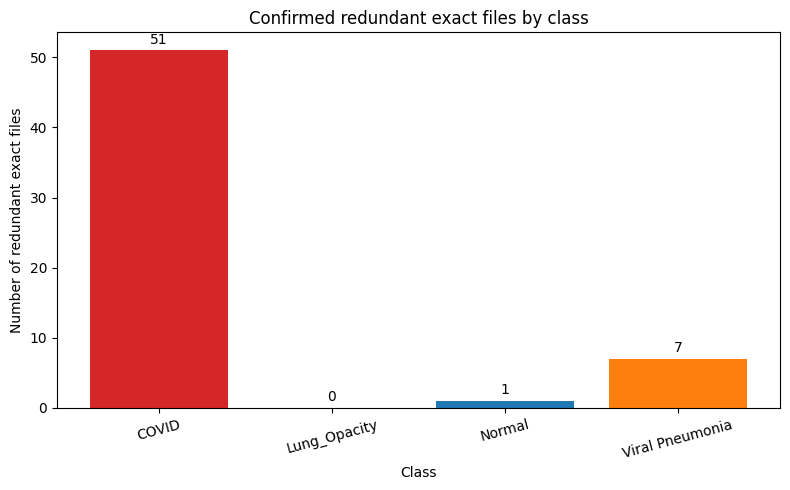

In [33]:

redundant_counts = (
    redundant_df
    .groupby("class")
    .size()
    .reindex(classes, fill_value=0)
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    redundant_counts.index,
    redundant_counts.values,
    color=["#d62728", "#2ca02c", "#1f77b4", "#ff7f0e"]

)

ax.set_xlabel("Class")
ax.set_ylabel("Number of redundant exact files")
ax.set_title("Confirmed redundant exact files by class")

for bar, count in zip(bars, redundant_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(count),
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    "duplicate_distribution_report.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [29]:
mask_report = []
for c in classes:
    img_files = {f.name for f in class_files[c]}
    mask_dir = dataset_path / c / MASKS_SUBDIR
    mask_files = {f.name for f in mask_dir.glob("*.png")} if mask_dir.exists() else set()
    missing = img_files - mask_files
    mask_report.append({
        "class": c,
        "n_images": len(img_files),
        "n_masks": len(mask_files),
        "n_missing_masks": len(missing),
    })

print(pd.DataFrame(mask_report))

             class  n_images  n_masks  n_missing_masks
0            COVID      3616     3616                0
1     Lung_Opacity      6012     6012                0
2           Normal     10192    10192                0
3  Viral Pneumonia      1345     1345                0


In [ ]:
vp = props_df[
    (props_df["class"] == "Viral Pneumonia") &
    (props_df["type"] == "images")
]

print(
    vp.groupby("mode")["size_kb"].describe()
)